# 05 - Self-attention, from the intuition up

The bigram saw a single character. A Transformer lets every token look back over all the earlier tokens and pull in whatever is relevant. That mechanism is **self-attention**, and it is the one idea that makes language models work.

Here is why it matters. When you read "the trophy did not fit in the suitcase because *it* was too big," your eye glances back to work out what "it" refers to. The bigram cannot do that, because it sees only the character immediately before. Attention is exactly that glance backward, turned into arithmetic. We will build it in four small steps, each a small change to the one before.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1337)
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True); e = np.exp(x); return e / e.sum(axis=axis, keepdims=True)

# a toy batch: B sequences, T tokens each, C features per token
B, T, C = 4, 8, 32
x = np.random.randn(B, T, C)
print("input:", x.shape, "  (batch, time, channels)")

input: (4, 8, 32)   (batch, time, channels)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>import numpy as np; np.random.seed(1337)</code>: the array toolbox, with randomness pinned for repeatable numbers.</li>
<li><code>B, T, C = 4, 8, 32</code>: three sizes: a <b>batch</b> of 4 sequences, <b>T</b>=8 tokens each, <b>C</b>=32 numbers describing each token.</li>
<li><code>x = np.random.randn(B, T, C)</code>: a 4&times;8&times;32 block of random numbers standing in for token embeddings. They're random because here we only care about the <i>mechanics</i> of mixing them.</li>
<li><code>def softmax(x, axis=-1): ...</code>: the same probabilities helper as always, on one line.</li>
<li><code>print("input:", x.shape, ...)</code>: confirm the (batch, time, channels) shape we'll carry through the whole notebook.</li>
</ul>
</details>

## Step 1: the simplest way to gather context, averaging the past

(First, a note on shapes, because everything from here on uses them. `B` is how many sequences we handle at once, `T` is how many tokens each sequence has, and `C` is how many numbers describe each token. So `x` is a block of numbers with shape `(B, T, C)`.)

What is the simplest way for token `t` to use its context? Simply average it with every token before it, giving a blurred summary of the story so far. One firm rule: a token may never look at the *future*. When the model is generating text, the future has not been written yet (predicting it is the model's whole job), so during training we forbid looking ahead as well. This "only look backward" rule is called **causality**, and we enforce it everywhere.

The double loop below makes the averaging obvious: token 0 is just itself, token 2 is the average of tokens 0, 1, and 2, and so on.

In [2]:
xbow = np.zeros_like(x)                     # "bag of words" = running average
for b in range(B):
    for t in range(T):
        xbow[b, t] = x[b, :t+1].mean(axis=0)   # mean of tokens 0..t
print("token 0 is itself: ", np.allclose(xbow[0,0], x[0,0]))
print("token 2 is mean of 0,1,2:", np.allclose(xbow[0,2], x[0,:3].mean(0)))

token 0 is itself:  True
token 2 is mean of 0,1,2: True


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>xbow = np.zeros_like(x)</code>: an all-zeros block the same shape as <code>x</code>, to fill in. ("bow" = bag-of-words, i.e. a running average.)</li>
<li><code>for b in range(B): for t in range(T):</code>: visit every sequence <code>b</code>, every position <code>t</code>.</li>
<li><code>x[b, :t+1]</code>: slice along time: tokens 0 through t (the <code>+1</code> because slices exclude their end). Only the past and the current token -- never the future.</li>
<li><code>.mean(axis=0)</code>: average those vectors across time, giving one blended 32-number summary for position t.</li>
<li><code>np.allclose(...)</code>: a sanity check that token 0's summary is just itself, and token 2's is the mean of tokens 0,1,2.</li>
</ul>
</details>

## Step 2: the same thing as a matrix multiply

That averaging loop is secretly a single **matrix multiply**, and seeing this is what unlocks attention. Stack the averaging weights into a `(T, T)` table called `wei`, where row `t` says how much token `t` draws from each earlier token. The whole gather then becomes `wei @ x`.

Look at the printed table: row 2 is `[0.33, 0.33, 0.33, 0, 0, ...]`, an equal third from tokens 0, 1, and 2 and nothing from the future. That **lower-triangular** shape (zeros above the diagonal, so each row reaches only backward, never forward) is what enforces causality, at no extra cost.

The key reframing is this: "who attends to whom" is just a `(T, T)` grid of weights. Right now every earlier token gets an equal share. The entire rest of attention is one upgrade: stop averaging equally, and let the data decide those weights.

In [3]:
tril = np.tril(np.ones((T, T)))             # 1s on/below the diagonal
wei = tril / tril.sum(axis=1, keepdims=True)  # normalize each row to average
xbow2 = wei @ x                              # (T,T) @ (B,T,C) -> (B,T,C) by broadcasting
print("matches the loop:", np.allclose(xbow, xbow2))
print("\nweight matrix (row t = how token t mixes the past):")
print(np.round(wei, 2))

matches the loop: True

weight matrix (row t = how token t mixes the past):
[[1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.5  0.5  0.   0.   0.   0.   0.   0.  ]
 [0.33 0.33 0.33 0.   0.   0.   0.   0.  ]
 [0.25 0.25 0.25 0.25 0.   0.   0.   0.  ]
 [0.2  0.2  0.2  0.2  0.2  0.   0.   0.  ]
 [0.17 0.17 0.17 0.17 0.17 0.17 0.   0.  ]
 [0.14 0.14 0.14 0.14 0.14 0.14 0.14 0.  ]
 [0.12 0.12 0.12 0.12 0.12 0.12 0.12 0.12]]


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>tril = np.tril(np.ones((T, T)))</code>: an 8&times;8 grid of 1s with everything <i>above</i> the diagonal zeroed ("tril" = lower triangle). Row t has 1s only in columns 0..t -- i.e. "position t may look at 0..t."</li>
<li><code>wei = tril / tril.sum(axis=1, keepdims=True)</code>: divide each row by how many 1s it has, turning it into equal shares that sum to 1.</li>
<li><code>xbow2 = wei @ x</code>: the punchline: multiplying by that (T,T) weight grid computes every position's average-of-the-past in a single matrix multiply. NumPy broadcasts it across the batch.</li>
<li><code>np.allclose(xbow, xbow2)</code>: proves the matmul gives exactly what the double loop gave.</li>
<li><code>np.round(wei, 2)</code>: print the weight grid so you can <i>see</i> row t mixing tokens 0..t equally, future columns at 0.</li>
</ul>
</details>

### Look at the averaging matrix

The cell above printed `wei` as numbers. Seen as a picture it is clearer: a lower-triangular staircase where row `t` spreads an equal share across tokens `0..t` and puts nothing on the future. This is the crude, fixed version of the weights that attention will soon learn instead.

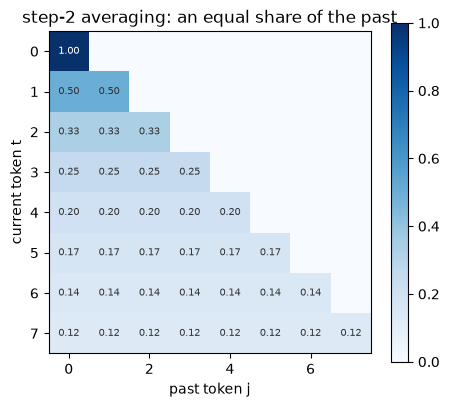

In [4]:
# The (T, T) averaging weights as an annotated heatmap.
fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(wei, cmap="Blues")
for i in range(T):
    for j in range(T):
        if wei[i, j] > 0:
            ax.text(j, i, f"{wei[i, j]:.2f}", ha="center", va="center",
                    fontsize=7, color="white" if wei[i, j] > 0.5 else "#333")
ax.set_xlabel("past token j"); ax.set_ylabel("current token t")
ax.set_title("step-2 averaging: an equal share of the past")
fig.colorbar(im); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>ax.imshow(wei, cmap="Blues")</code>: draw the 8&times;8 weight table as an image; darker means a larger share.</li>
<li>The double loop writes each nonzero weight into its cell, so you can read the exact numbers off the picture.</li>
<li>Row 0 is a lone <code>1.00</code> (token 0 has only itself); row 1 is <code>0.50, 0.50</code>; row 7 is eight equal <code>0.12</code>s.</li>
<li>The blank upper triangle is the causal rule: no token draws anything from the future. Attention keeps this exact triangular shape but replaces the equal shares with learned ones.</li>
</ul>
</details>

## Step 3: let the data set the weights, which is attention itself

Equal averaging is crude: a pronoun should lean heavily on its noun, not on every random word. So we let the **data** set the weights. The clearest way to picture this is a search engine, in which each token produces three things:

- a **query** `q`, meaning "what am I looking for?" (like the words you type into a search box),
- a **key** `k`, meaning "what do I contain?" (like the tags a document advertises),
- a **value** `v`, meaning "what I will pass on if you attend to me" (like the document's actual content).

These are three different jobs, so each gets its own learned projection (`W_q`, `W_k`, `W_v`, which are just matrices the model trains). To score how much token `i` should attend to token `j`, take the **dot product** `q_i . k_j`, the query-meets-key similarity from notebook 01. A high dot product means a good match, so the token pays more attention there.

The rest is machinery you already know: hide the future by setting those scores to negative infinity, apply softmax to each row so the weights add up to 1, and return the weighted sum of the values. The whole thing is one compact formula:

$$\text{attention}(Q,K,V) = \text{softmax}\!\left(\frac{Q K^{\top}}{\sqrt{d}}\right) V$$

In plain words, reading from the inside out: match every query against every key ($QK^{\top}$, where $K^{\top}$ just means the table of keys turned on its side so the multiplication lines up), tone the scores down by dividing by $\sqrt{d}$ (explained in the next cell), turn them into weights with softmax, and use those weights to blend the values ($\cdot\, V$). Unlike the bigram, the token itself decides where to look.

In [5]:
head_size = 16
# learned projections (random here; in the GPT these are trained)
W_q = np.random.randn(C, head_size) * 0.1
W_k = np.random.randn(C, head_size) * 0.1
W_v = np.random.randn(C, head_size) * 0.1

q = x @ W_q          # (B,T,head_size) - queries
k = x @ W_k          # (B,T,head_size) - keys
v = x @ W_v          # (B,T,head_size) - values

# affinities: every query dotted with every key
scores = q @ k.transpose(0, 2, 1)            # (B,T,T)
scores = scores / head_size**0.5             # scale (step 4, below)

mask = np.tril(np.ones((T, T)))              # causal mask
scores = np.where(mask == 0, -np.inf, scores)  # future -> -inf -> 0 after softmax
attn = softmax(scores, axis=-1)              # (B,T,T) each row sums to 1
out = attn @ v                               # (B,T,head_size) weighted sum of values
print("attention output:", out.shape)
print("causal? upper triangle is zero:", np.allclose(np.triu(attn[0], k=1), 0))
print("rows sum to 1:", np.allclose(attn[0].sum(1), 1))

attention output: (4, 8, 16)
causal? upper triangle is zero: True
rows sum to 1: True


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>head_size = 16</code>: each attention head will boil a token down to a 16-number query/key/value.</li>
<li><code>W_q = np.random.randn(C, head_size) * 0.1</code> (and W_k, W_v) -- the three learned projections. Multiplying a token's 32 numbers by a (32,16) grid gives its 16-number query / key / value. (Random here; in the GPT these are trained.)</li>
<li><code>q = x @ W_q</code> (and k, v) -- apply each projection to every token in every sequence at once: shape (B, T, 16).</li>
<li><code>scores = q @ k.transpose(0, 2, 1)</code>: <code>transpose</code> swaps the last two axes so the matmul lines up; the result is <b>every query dotted with every key</b> -- a (B, T, T) grid of match scores.</li>
<li><code>scores = scores / head_size**0.5</code>: divide by &radic;16 = 4: the scaling trick (next cell shows why).</li>
<li><code>mask = np.tril(np.ones((T, T)))</code>: the same lower-triangle mask: 1 where attending is allowed, 0 for the future.</li>
<li><code>scores = np.where(mask == 0, -np.inf, scores)</code>: wherever the mask is 0, overwrite the score with negative infinity; everywhere else keep it. After softmax, -inf becomes exactly 0 weight.</li>
<li><code>attn = softmax(scores, axis=-1)</code>: turn each row of scores into weights that sum to 1.</li>
<li><code>out = attn @ v</code>: blend the value vectors by those weights: each token's output is its personalized weighted sum of the past.</li>
<li><code>np.triu(attn[0], k=1)</code>: the strictly-upper triangle (future positions); checking it's all zeros proves no information leaked backward in time.</li>
</ul>
</details>

### The matrix itself

The checks above confirm the mask and the softmax. But `attn[0]` is a grid small enough to simply look at, and it repays looking at, because everything built so far is visible in its shape at once. (There is a heatmap of this further down; the numbers are worth reading first.)

In [6]:
np.set_printoptions(linewidth=100,
                    suppress=True)
print(np.round(attn[0], 2))


[[1.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.37 0.63 0.   0.   0.   0.   0.   0.  ]
 [0.26 0.35 0.39 0.   0.   0.   0.   0.  ]
 [0.18 0.31 0.3  0.2  0.   0.   0.   0.  ]
 [0.25 0.2  0.13 0.29 0.12 0.   0.   0.  ]
 [0.14 0.13 0.17 0.18 0.21 0.17 0.   0.  ]
 [0.22 0.11 0.13 0.23 0.12 0.09 0.1  0.  ]
 [0.09 0.19 0.12 0.09 0.13 0.09 0.12 0.17]]


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>np.set_printoptions(linewidth=100, suppress=True)</code>: print the grid on wide lines and without scientific notation, so it can be read as a table.</li>
<li><code>print(np.round(attn[0], 2))</code>: one question asked 64 times: how much does the token in row <code>t</code> take from the token in column <code>s</code>? Four things are now visible rather than asserted. <b>The empty upper triangle is the mask</b> &mdash; that is <code>-np.inf</code> going into softmax and exactly 0 coming out, so nothing leaked backward in time. <b>Row 0 is 1.0 and nothing else</b>: the first token has only itself to look at, so softmax over a single permitted position has no choice. <b>Every row sums to 1</b>: attention never creates or destroys weight, it only chooses where to spend a fixed budget, which is why row 7 spreads the same 1.0 over eight positions and its entries are all small. <b>The weights are uneven</b>: row 1 gives 0.63 to itself and 0.37 to token 0, where equal shares would have been 0.50 and 0.50 &mdash; that gap is the data setting its own weights.</li>
</ul>
</details>

### Open up one row of the attention matrix

`attn` is a `(B, T, T)` block, which is a lot to take in at once. So follow a single query token all the way through -- token `t = 4` in the first sequence -- and watch its score against every other token become a set of weights. The recomputed weights match row 4 of the full `attn`, and their weighted sum of values matches `out` for that token, so this one row is the whole mechanism in miniature.

token t=4: query shape (16,), scored against 8 keys
raw scores  q.k/sqrt(hs): [ 0.31  0.08 -0.38  0.45 -0.41 -0.13  0.17 -0.32]
after causal mask       : [ 0.31  0.08 -0.38  0.45 -0.41  -inf  -inf  -inf]
after softmax (weights) : [0.255 0.202 0.128 0.292 0.124 0.    0.    0.   ]  sum = 1.0
matches row 4 of attn   : True
blended value == out[0,4]: True


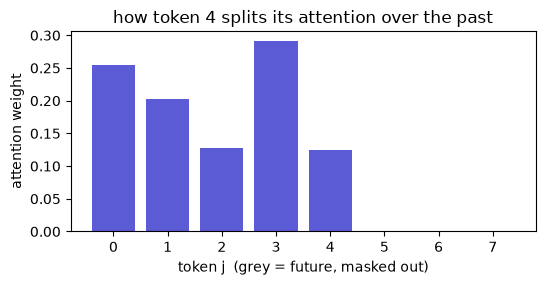

In [7]:
# Follow token t=4: query . keys -> scale -> causal mask -> softmax -> weights.
t = 4
qt = q[0, t]                                   # this token's query vector (head_size,)
raw = (k[0] @ qt) / head_size**0.5             # score against every token's key (T,)
masked = raw.copy(); masked[t+1:] = -np.inf    # a token may not look at the future
w = softmax(masked)                            # weights over tokens 0..t (future = 0)

print(f"token t={t}: query shape {qt.shape}, scored against {T} keys")
print("raw scores  q.k/sqrt(hs):", np.round(raw, 2))
print("after causal mask       :", np.round(masked, 2))
print("after softmax (weights) :", np.round(w, 3), " sum =", round(w.sum(), 3))
print("matches row 4 of attn   :", np.allclose(w, attn[0, t]))
print("blended value == out[0,4]:", np.allclose(w @ v[0], out[0, t]))

fig, ax = plt.subplots(figsize=(6, 2.6))
colors = ["#5b5bd6" if j <= t else "#d9d9e0" for j in range(T)]
ax.bar(range(T), w, color=colors)
ax.set_xticks(range(T)); ax.set_xlabel("token j  (grey = future, masked out)")
ax.set_ylabel("attention weight"); ax.set_title(f"how token {t} splits its attention over the past")
plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>qt = q[0, t]</code>: pull out token 4's query vector (16 numbers).</li>
<li><code>raw = (k[0] @ qt) / head_size**0.5</code>: dot that query against every token's key, then apply the step-4 scale -- one score per token.</li>
<li><code>masked[t+1:] = -np.inf</code>: blank out tokens 5, 6, 7 (the future); softmax turns <code>-inf</code> into exactly 0.</li>
<li><code>w = softmax(masked)</code>: the five surviving scores become weights that sum to 1.</li>
<li>The two <code>allclose</code> checks prove this hand-trace equals row 4 of the full <code>attn</code> matrix, and that blending the values with these weights gives the same <code>out</code> the batched code produced.</li>
<li>The bar chart shows where token 4 actually looks: taller bars are tokens it weights more, the greyed bars are the masked future.</li>
</ul>
</details>

## Step 4: why divide by the square root of the head size?

One small detail keeps attention healthy at the start of training. A dot product adds up `head_size` separate little products (`head_size` is just the length of the query and key vectors), so with longer vectors the scores naturally grow larger. Feed large numbers into softmax and it becomes **peaky**, meaning almost all the weight piles onto a single token. That is a problem early on, because a peaky softmax produces very small gradients (it is already acting "certain"), so the model can barely learn, and what it is certain about is random nonsense, since nothing has been trained yet.

Dividing every score by the square root of `head_size` cancels that growth and keeps the scores moderate, so attention starts out **soft**, meaning spread out, and therefore trainable. The demo makes it concrete: with no scaling the top weight is already 0.87 (for head size 16) or 0.94 (for head size 256), which is dangerously peaky, while the scaled version sits at a gentle 0.32 or 0.24.

In [8]:
# Dot products grow with head_size, which makes softmax collapse toward one-hot.
# Compare one query against 8 keys, for two head sizes, with and without the scale:
rng = np.random.default_rng(0)
for hs in [16, 256]:
    qq = rng.standard_normal(hs); kk = rng.standard_normal((8, hs))
    s = kk @ qq
    print(f"head_size={hs:4d}:  unscaled max weight = {softmax(s).max():.2f}    "
          f"scaled max weight = {softmax(s / hs**0.5).max():.2f}")
print("\nBigger head_size -> unscaled softmax gets peaky (toward 1.0, starving gradients);")
print("the 1/sqrt(head_size) scale keeps it soft and trainable.")

head_size=  16:  unscaled max weight = 0.87    scaled max weight = 0.32
head_size= 256:  unscaled max weight = 0.94    scaled max weight = 0.24

Bigger head_size -> unscaled softmax gets peaky (toward 1.0, starving gradients);
the 1/sqrt(head_size) scale keeps it soft and trainable.


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>rng = np.random.default_rng(0)</code>: a seeded random generator so the demo numbers are repeatable.</li>
<li><code>for hs in [16, 256]:</code>: try a small and a large head size.</li>
<li><code>qq = rng.standard_normal(hs); kk = rng.standard_normal((8, hs))</code>: one random query and 8 random keys of that size.</li>
<li><code>s = kk @ qq</code>: the 8 match scores. With more dimensions added up, the scores naturally swing bigger.</li>
<li><code>softmax(s).max()</code>: the largest attention weight <i>without</i> scaling. Near 1.0 means all the attention piled onto one token (peaky -- bad early in training).</li>
<li><code>softmax(s / hs**0.5).max()</code>: the same scores divided by &radic;(head size) first: attention stays spread out and trainable.</li>
</ul>
</details>

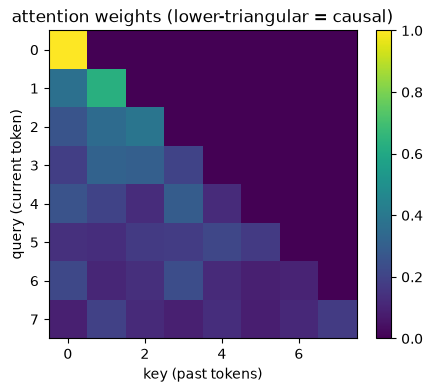

In [9]:
# visualize who attends to whom (row = query token, col = key token)
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(attn[0], cmap="viridis")
ax.set_xlabel("key (past tokens)"); ax.set_ylabel("query (current token)")
ax.set_title("attention weights (lower-triangular = causal)")
fig.colorbar(im); plt.show()

<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>fig, ax = plt.subplots(figsize=(5,4))</code>: make a single plot panel to draw the heatmap on.</li>
<li><code>ax.imshow(attn[0], cmap="viridis")</code>: draw the first sequence's (T,T) attention grid as colors: brighter = more attention.</li>
<li><code>ax.set_xlabel(...); ax.set_ylabel(...)</code>: label the axes: columns are the past tokens being looked at, rows are the token doing the looking.</li>
<li><code>fig.colorbar(im); plt.show()</code>: add the color scale and render. The bright lower triangle and dark upper triangle <i>is</i> causality, made visible.</li>
</ul>
</details>

## Package it as a function

Those few lines are one **attention head**: query, key, value, score, mask, softmax, blend. Here it is wrapped into a single function that returns exactly the same output. We will reuse this precise logic in PyTorch later, where it shrinks to about six lines and the gradients are handled for us.

In [10]:
def attention_head(x, W_q, W_k, W_v):
    B, T, C = x.shape; hs = W_q.shape[1]
    q, k, v = x @ W_q, x @ W_k, x @ W_v
    scores = (q @ k.transpose(0,2,1)) / hs**0.5
    scores = np.where(np.tril(np.ones((T,T))) == 0, -np.inf, scores)
    return softmax(scores, -1) @ v

out2 = attention_head(x, W_q, W_k, W_v)
print("output:", out2.shape, " same as before:", np.allclose(out, out2))

output: (4, 8, 16)  same as before: True


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>def attention_head(x, W_q, W_k, W_v):</code>: the previous cells folded into one reusable function.</li>
<li><code>B, T, C = x.shape</code>: read the input's three sizes back out (tuple unpacking).</li>
<li><code>hs = W_q.shape[1]</code>: read the head size off the projection grid instead of hard-coding it.</li>
<li><code>return softmax(scores, -1) @ v</code>: the same project &rarr; score &rarr; scale &rarr; mask &rarr; softmax &rarr; blend, compressed.</li>
<li><code>np.allclose(out, out2)</code>: the function reproduces the step-by-step result exactly.</li>
</ul>
</details>

## Many heads at once

One head mixes information in one particular way, and you can think of a trained head as having a specialty, like "pronouns, find your nouns." But sentences hold many kinds of relationship at once: grammar, nearby adjectives, long-range topic. So real transformers run several heads in parallel, each with its own `W_q`, `W_k`, `W_v` (its own notion of what to ask and what to offer) and concatenate their outputs side by side.

In [11]:
np.random.seed(7)
heads = []
for h in range(4):
    Wq = np.random.randn(C, 8) * 0.1
    Wk = np.random.randn(C, 8) * 0.1
    Wv = np.random.randn(C, 8) * 0.1
    heads.append(
        attention_head(x, Wq, Wk, Wv))
multi = np.concatenate(heads, axis=-1)
print("4 heads of size 8 ->", multi.shape)


4 heads of size 8 -> (4, 8, 32)


<details class="code-read"><summary>Line by line: what each line does</summary>
<ul>
<li><code>np.random.seed(7)</code>: pin the random draws so every run gives the same four heads.</li>
<li><code>for h in range(4):</code>: four independent heads, each with its own three projection matrices.</li>
<li><code>np.random.randn(C, 8) * 0.1</code>: each head projects the C=32 input channels down to just 8, so one head produces an 8-number output per token. The <code>* 0.1</code> keeps the starting weights small.</li>
<li><code>attention_head(x, Wq, Wk, Wv)</code>: the function from the cell above, run once per head. Each head attends with different weights, so each gathers a different kind of context.</li>
<li><code>np.concatenate(heads, axis=-1)</code>: glue the four outputs side by side along the channel axis: 4 &times; 8 = 32 numbers per token, matching the input width. <code>axis=-1</code> means the last axis.</li>
</ul>
</details>

This is **multi-head attention**. Notice that the output shape is the same as the input, `(4, 8, 32)`: four sequences, eight tokens each, 32 numbers per token. Splitting 32 channels across four heads of 8 is what keeps several heads affordable &mdash; four heads each doing a quarter-width job cost about the same as one full-width head.

Chapter 25 wires this properly into the transformer block, along with position information and the feed-forward layer.

## Recap

Self-attention in one sentence: each token builds query, key, and value vectors, scores every earlier token by query-key similarity, hides the future, turns the scores into weights with softmax, and returns the weighted sum of the values. One head mixes information in one particular way, for example "pronouns, find your nouns."

Next, notebook 06 runs several heads in parallel (so the model can look for several kinds of relationship at once), adds position information and a small feed-forward layer, and wraps it all into the **Transformer block** that we stack to build a GPT.